In [3]:
!pip install prophet

   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.3 MB 487.6 kB/s eta 0:00:28
   ---------------------------------------- 0.0/13.3 MB 487.6 kB/s eta 0:00:28
   ---------------------------------------- 0.0/13.3 MB 487.6 kB/s eta 0:00:28
   ---------------------------------------- 0.1/13.3 MB 272.3 kB/s eta 0:00:49
   ---------------------------------------- 0.1/13.3 MB 327.7 kB/s eta 0:00:41
   ---------------------------------------- 0.1/13.3 MB 399.4 kB/s eta 0:00:34
   ---------------------------------------- 0.2/13.3 MB 458.0 kB/s eta 0:00:29
   ---------------------------------------- 0.2/13.3 MB 458.0 kB/s eta 0:00:29
    --------------------------------------- 0.2/13.3 MB 444.2 kB/s eta 0:00:30
    --------------------------------------- 0.2/13.3 MB 464.5 kB/s eta 0:00:29
    --------------------------------------- 0.3/13.3 MB 577.4 kB/s eta

In [4]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [7]:
data_path = os.path.abspath('C:\\Dhanushi\\PrinciplesOfDataScience_Group2\\data\\time_series_data.csv') 
df = pd.read_csv(data_path)
# df = pd.read_csv('c:\\Users\\Administrator\\Documents\\GitHub\\PrinciplesOfDataScience_Group2\\data\\time_series_data.csv')
df.head()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
0,1,197,66,266,113,2,1,18
1,2,153,44,264,74,1,2,21
2,3,128,55,317,116,0,1,19
3,4,133,57,390,70,0,2,17
4,5,120,47,440,141,1,1,18


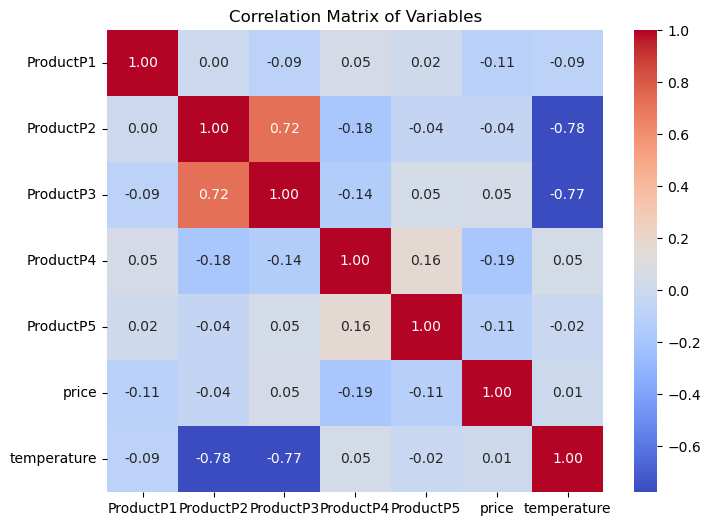

In [8]:
# Compute the correlation matrix
corr_matrix = df.drop(columns=["t"]).corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Variables")
plt.show()

c:\Users\ABINEYAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ABINEYAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ABINEYAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ABINEYAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory le

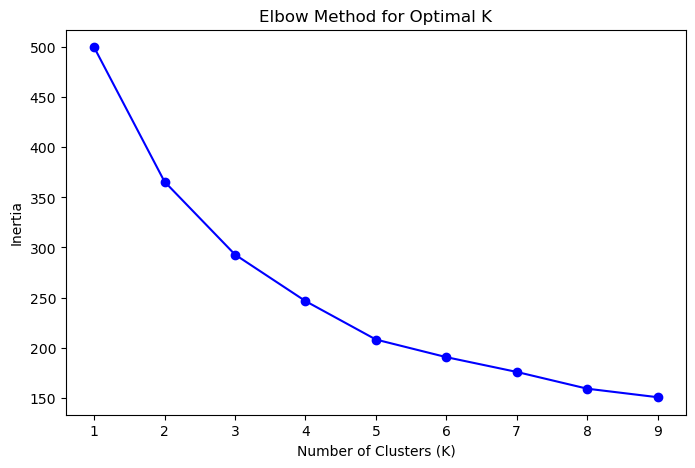

In [9]:
# Select only product columns for clustering
product_columns = ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]
X = df[product_columns]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

c:\Users\ABINEYAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


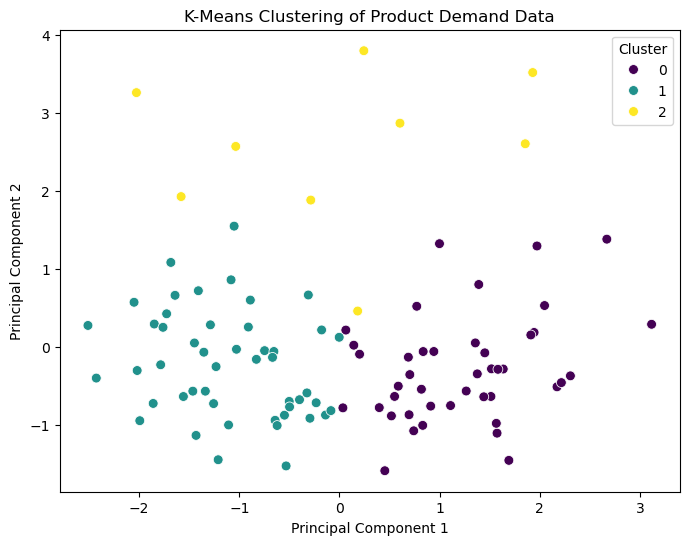

In [10]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualizing cluster distribution using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["Cluster"], palette="viridis", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Product Demand Data")
plt.legend(title="Cluster")
plt.show()

In [11]:
# Apply PCA with all components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Print results
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.3582 (Cumulative: 0.3582)
PC2: 0.2276 (Cumulative: 0.5857)
PC3: 0.1989 (Cumulative: 0.7847)
PC4: 0.1609 (Cumulative: 0.9456)
PC5: 0.0544 (Cumulative: 1.0000)


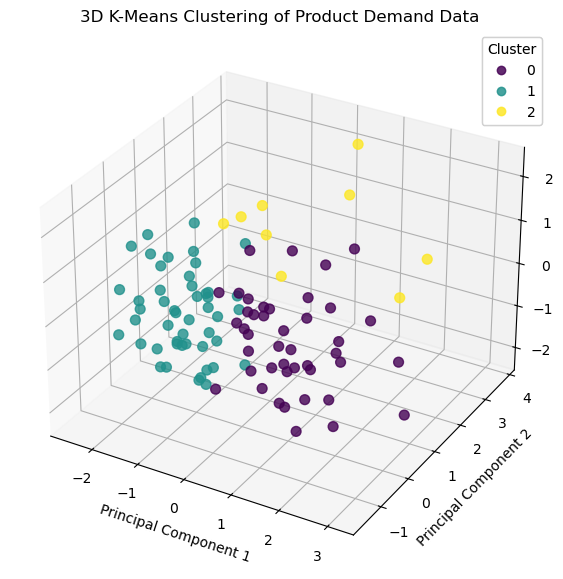

In [12]:
# Apply PCA with n_components=3
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster colors
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                      c=df["Cluster"], cmap="viridis", s=50, alpha=0.8)

# Labels and title
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D K-Means Clustering of Product Demand Data")

# Add a legend
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

# Show the plot
plt.show()

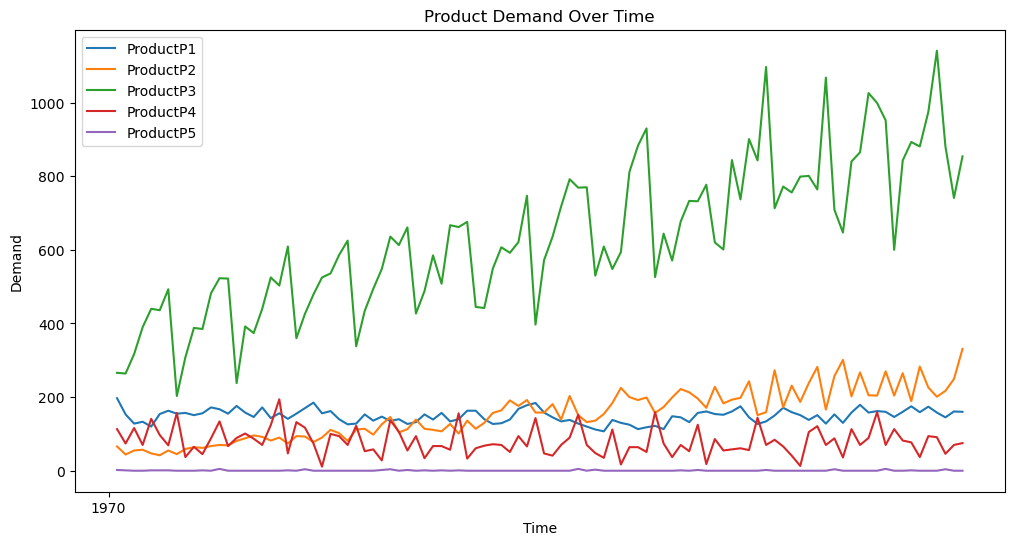

In [13]:
# Convert time index (if needed)
df["t"] = pd.to_datetime(df["t"])

# Plot product demand over time
plt.figure(figsize=(12, 6))
for col in ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]:
    plt.plot(df["t"], df[col], label=col)
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Product Demand Over Time")
plt.show()

In [14]:
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is non-stationary.")

# Test for one product
check_stationarity(df["ProductP1"])
check_stationarity(df["ProductP2"])
check_stationarity(df["ProductP3"])
check_stationarity(df["ProductP4"])
check_stationarity(df["ProductP5"])

ADF Statistic: -5.675633394124424
p-value: 8.718203196079533e-07
The series is stationary.
ADF Statistic: -0.8615506650073318
p-value: 0.8003705824294144
The series is non-stationary.
ADF Statistic: -0.23487312238267008
p-value: 0.9342351563563018
The series is non-stationary.
ADF Statistic: -11.455482825126904
p-value: 5.7205444486806576e-21
The series is stationary.
ADF Statistic: -11.152511228832307
p-value: 2.9198433474930307e-20
The series is stationary.


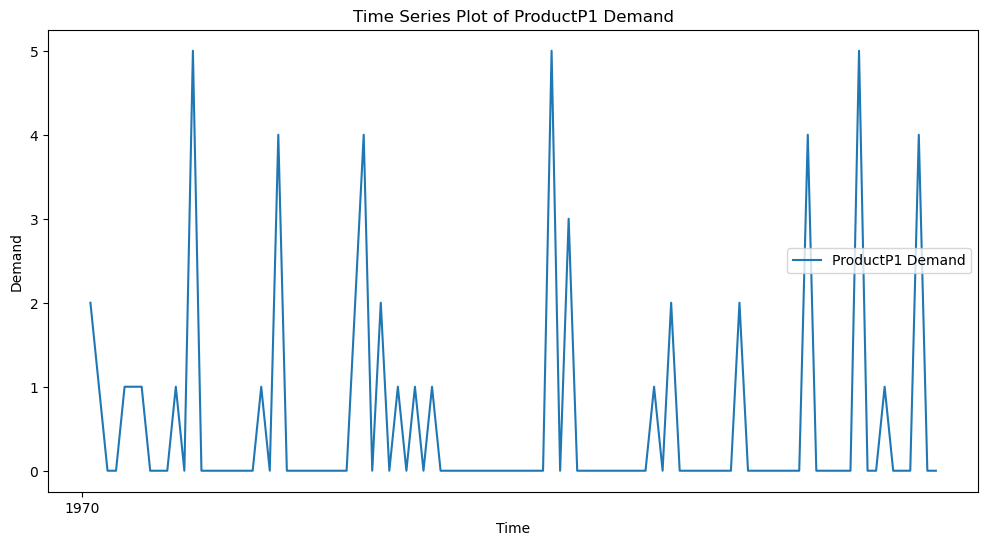

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df["t"], df["ProductP5"], label="ProductP1 Demand")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Time Series Plot of ProductP1 Demand")
plt.legend()
plt.show()

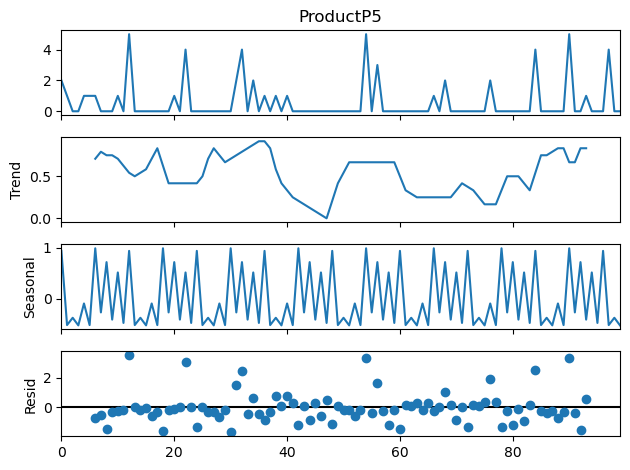

In [16]:
result = seasonal_decompose(df["ProductP5"], period=12, model="additive")
result.plot()
plt.show()

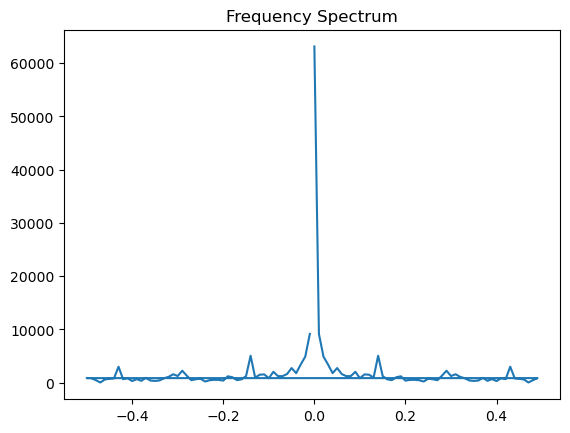

In [17]:
fft = np.fft.fft(df["ProductP3"])
freqs = np.fft.fftfreq(len(df["ProductP3"]))

plt.plot(freqs, abs(fft))
plt.title("Frequency Spectrum")
plt.show()

In [18]:
model = SARIMAX(df["ProductP1"], order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          ProductP1   No. Observations:                  100
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -366.334
Date:                            Wed, 12 Feb 2025   AIC                            742.669
Time:                                    12:22:37   BIC                            754.998
Sample:                                         0   HQIC                           747.634
                                            - 100                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5226      0.132      3.958      0.000       0.264       0.781
ma.L1         -0.9006      0.083   

12:22:41 - cmdstanpy - INFO - Chain [1] start processing
12:22:43 - cmdstanpy - INFO - Chain [1] done processing


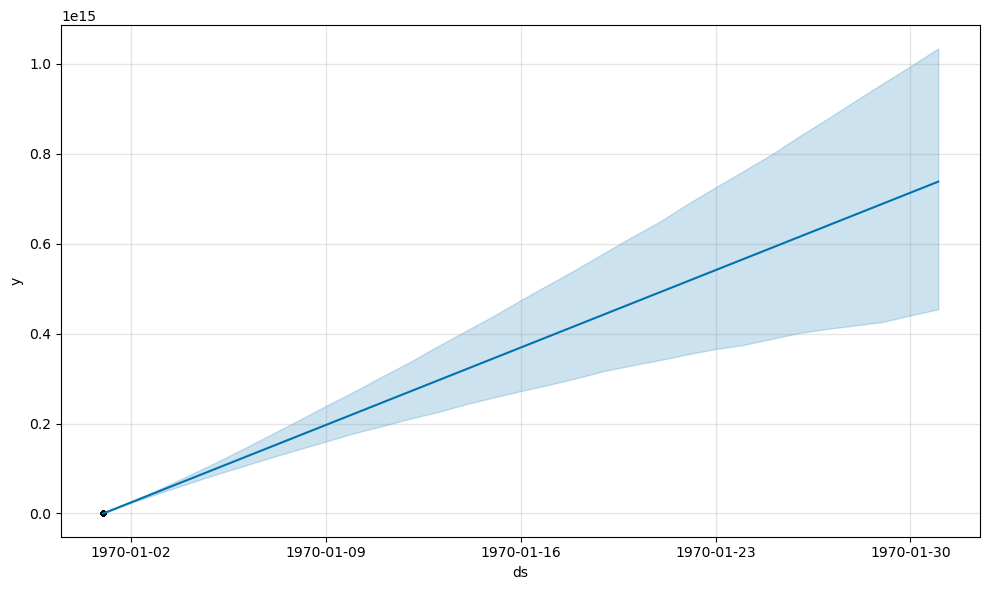

In [19]:
# Prepare data for Prophet
df_prophet = df.rename(columns={"t": "ds", "ProductP1": "y"})

# Fit model
model = Prophet()
model.fit(df_prophet)

# Make future predictions
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.show()

In [20]:
forecast[101:130]

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
101,1970-01-03 00:00:00.000000100,4.919755e+13,4.492666e+13,5.370661e+13,4.492666e+13,5.370661e+13,0.0,0.0,0.0,0.0,0.0,0.0,4.919755e+13
102,1970-01-04 00:00:00.000000100,7.379632e+13,6.543001e+13,8.245198e+13,6.543001e+13,8.245198e+13,0.0,0.0,0.0,0.0,0.0,0.0,7.379632e+13
103,1970-01-05 00:00:00.000000100,9.839510e+13,8.562717e+13,1.118627e+14,8.562717e+13,1.118627e+14,0.0,0.0,0.0,0.0,0.0,0.0,9.839510e+13
104,1970-01-06 00:00:00.000000100,1.229939e+14,1.046831e+14,1.428463e+14,1.046831e+14,1.428463e+14,0.0,0.0,0.0,0.0,0.0,0.0,1.229939e+14
105,1970-01-07 00:00:00.000000100,1.475926e+14,1.237373e+14,1.744448e+14,1.237373e+14,1.744448e+14,0.0,0.0,0.0,0.0,0.0,0.0,1.475926e+14
106,1970-01-08 00:00:00.000000100,1.721914e+14,1.419869e+14,2.064871e+14,1.419869e+14,2.064871e+14,0.0,0.0,0.0,0.0,0.0,0.0,1.721914e+14
107,1970-01-09 00:00:00.000000100,1.967902e+14,1.599880e+14,2.391516e+14,1.599880e+14,2.391516e+14,0.0,0.0,0.0,0.0,0.0,0.0,1.967902e+14
108,1970-01-10 00:00:00.000000100,2.213890e+14,1.782750e+14,2.705148e+14,1.782750e+14,2.705148e+14,0.0,0.0,0.0,0.0,0.0,0.0,2.213890e+14
109,1970-01-11 00:00:00.000000100,2.459877e+14,1.940130e+14,3.040187e+14,1.940130e+14,3.040187e+14,0.0,0.0,0.0,0.0,0.0,0.0,2.459877e+14
110,1970-01-12 00:00:00.000000100,2.705865e+14,2.105240e+14,3.361416e+14,2.105240e+14,3.361416e+14,0.0,0.0,0.0,0.0,0.0,0.0,2.705865e+14
